In [714]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random



# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# I'm ramping lamda up to see if I can find  a good value for it
# looks like 2


# Consider dropping the decay term during adversarial training
# Train on equal parts from all classes 
# simplify the adversary network
# change number of classes


#lambda = 2
# good seeds: 42, 43, 45
# bad seeds: 44

# Define important parameters

In [794]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 2.0

def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(45))

In [795]:
class Adversary(nn.Module):
    def __init__(self, n_classes, input_dim=1, hidden1=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, n_classes)   # outputs raw logits for CrossEntropyLoss
            )
        
    def forward(self, x):
        # make the shape (N,1) in a way that is robust for squeezed / unsqueezed classifier outputs
        x = x.view(x.size(0), -1)
        return self.net(x)  # returns shape (N, n_classes)

# Load and setup the data

In [796]:
# Read tritrig, wab, phiKK, and data files
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_limited.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_limited.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_limited.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  120739
phiKK:  4086
wab:  6596


In [797]:
# Make Training set with 20000 tritrig, 4000 phiKK, 4000 wab
tritrig_train = df_tritrig[0:20000]
wab_train = df_wab[0:3000]
phiKK_train = df_phiKK[0:3000]

# Combine and shuffle all training data
df_train = pd.concat([tritrig_train, phiKK_train, wab_train], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Get edges in invariant mass classes for one-hot encoding
# To be used for adverserial labels
# The edges are chosen such that each bin has equal number of background events
one_hot_edges = mytools.get_one_hot_edges(mytools.get_InvM( pd.concat([df_tritrig, df_wab], ignore_index=True, sort=False) ), n_bins=Num_classes)

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)

# Make testing set with remaining events
tritrig_test = df_tritrig[20000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[3000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[3000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels( mytools.get_InvM(df_test), one_hot_edges)


X_train_bkg =  X_train[y_train == 0]
y_train_bkg =  y_train[y_train == 0]
y_adv_train_bkg = y_adv_train[y_train == 0]

X_val_bkg =  X_val[y_val == 0]
y_val_bkg =  y_val[y_val == 0]
y_adv_val_bkg = y_adv_val[y_val == 0]

X_test_bkg =  X_test[y_test == 0]
y_test_bkg =  y_test[y_test == 0]
y_adv_test_bkg = y_adv_test[y_test == 0]

df_test["InvM"] = mytools.get_InvM(df_test) 



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_56792/2779207915.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_56792/2779207915.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_56792/2779207915.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

## Setup dataloaders

In [798]:
bsize = 2000

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


## Initialize model, objective function, and optimizer

In [799]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-5)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.9999)


## Pre-train the classifier

In [800]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 4000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.643833
Validation loss: 0.700234 

Epoch 2
-------------------------------
Training loss: 0.623144
Validation loss: 0.692088 

Epoch 3
-------------------------------
Training loss: 0.608525
Validation loss: 0.676451 

Epoch 4
-------------------------------
Training loss: 0.596529
Validation loss: 0.658444 

Epoch 5
-------------------------------
Training loss: 0.589101
Validation loss: 0.634824 

Epoch 6
-------------------------------
Training loss: 0.581217
Validation loss: 0.595969 

Epoch 7
-------------------------------
Training loss: 0.573403
Validation loss: 0.570656 

Epoch 8
-------------------------------
Training loss: 0.566580
Validation loss: 0.555752 

Epoch 9
-------------------------------
Training loss: 0.561037
Validation loss: 0.548763 

Epoch 10
-------------------------------
Training loss: 0.556177
Validation loss: 0.546960 

Epoch 11
-------------------------------
Training loss: 0.551180
Validation los

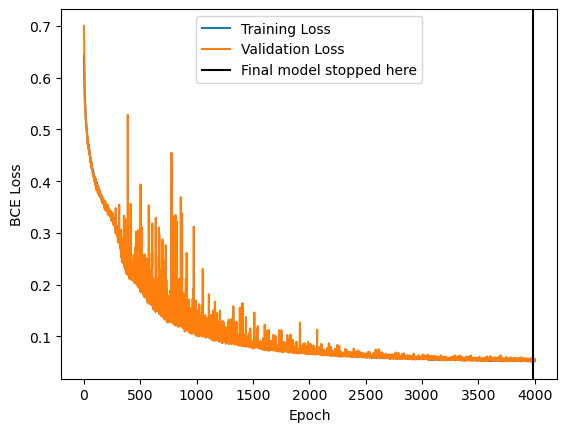

In [801]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

Test AUROC: 0.9957


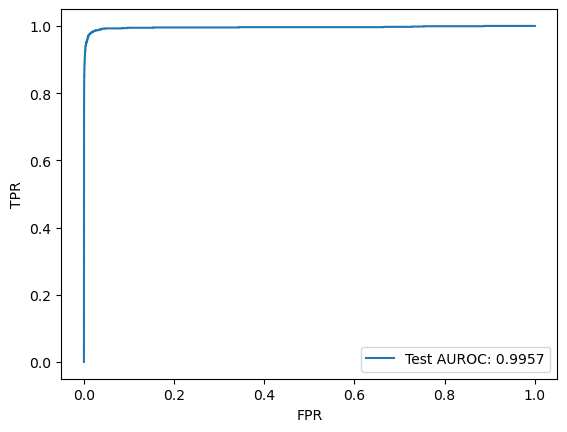

In [802]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

In [803]:
# Store the pretrained classifier labels
df_test["Class_pre"] = test_pred

# Save the pretrained classifier model
#torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/patch/pretrained_classifier_2021_v9_pass5_run"+str(run)+"_limited.pt")


# Setup the adversary model

## Initialize model, objective function, and optimizer

In [804]:
adv = Adversary(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss()  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-5)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=0.999)


## Setup dataloaders

In [805]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train_bkg.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train_bkg))
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val_bkg.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val_bkg))
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relavent for testing
test_adv_dataset = TensorDataset(torch.from_numpy(X_test_bkg.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_test_bkg))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)

## Pre-train the adversary leaving classifier weights fixed

In [806]:
def train_adv(dataloader, classifier, adv, loss_fn, optimizer, scheduler_adv, device, print_results=True):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    classifier.eval()
    adv.train()
    train_loss = 0
    
    for batch, (X, y) in enumerate(dataloader):
        
        X, y = X.to(device), y.to(device)

        # Forward pass through classifier
        with torch.no_grad():
            p = classifier(X)

        # Compute prediction error
        pred = adv(p)
        loss = loss_fn(pred, y)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler_adv.step()
            
        train_loss += loss.item()
            
            
    train_loss /= num_batches
    if print_results:
        print(f"Training loss: {train_loss:>7f}")
    return(train_loss)

# Training Loop
def validate_adv(dataloader, classifier, adv, loss_fn, device, print_results=True):
    num_batches = len(dataloader)
    classifier.eval()
    adv.eval()
    val_loss = 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):

            X, y = X.to(device), y.to(device)

            p = classifier(X)

            pred = adv(p)
            loss = loss_fn(pred, y) # since we set reduction='none', this is now a vector of losses, one per sample in the batch
            
            val_loss += loss.item()
        
    val_loss /= num_batches
    if print_results:
        print(f"Validation loss: {val_loss:>7f} \n")
    return(val_loss)

In [807]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 1000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)
    

            
print("Done!")

Epoch 1
-------------------------------
Training loss: 2.588445
Validation loss: 2.581070 

Epoch 2
-------------------------------
Training loss: 2.582628
Validation loss: 2.574650 

Epoch 3
-------------------------------
Training loss: 2.575291
Validation loss: 2.570168 

Epoch 4
-------------------------------
Training loss: 2.570874
Validation loss: 2.562568 

Epoch 5
-------------------------------
Training loss: 2.564665
Validation loss: 2.557276 

Epoch 6
-------------------------------
Training loss: 2.558584
Validation loss: 2.552103 

Epoch 7
-------------------------------
Training loss: 2.553387
Validation loss: 2.547115 

Epoch 8
-------------------------------
Training loss: 2.548975
Validation loss: 2.542483 

Epoch 9
-------------------------------
Training loss: 2.543084
Validation loss: 2.537226 

Epoch 10
-------------------------------
Training loss: 2.538570
Validation loss: 2.532408 

Epoch 11
-------------------------------
Training loss: 2.532775
Validation los

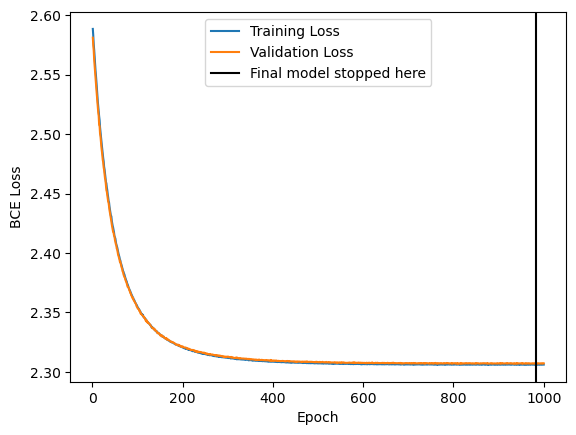

In [808]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

# Train full adverserial neural network

# Setup dataloaders

In [809]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train))
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

train_full_dataset_bkg = TensorDataset(torch.from_numpy(X_train_bkg.to_numpy().astype(np.float32))  , torch.from_numpy(y_train_bkg.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train_bkg))
train_full_loader_bkg = DataLoader(train_full_dataset_bkg, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val))
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset_bkg = TensorDataset(torch.from_numpy(X_val_bkg.to_numpy().astype(np.float32))  , torch.from_numpy(y_val_bkg.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val_bkg))
val_full_loader_bkg = DataLoader(val_full_dataset_bkg, batch_size=bsize, shuffle=True)


## Define loss functions

In [810]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss() 

def full_loss(output_clas, output_adv, target_clas, target_adv, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    loss2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [811]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-7, betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=1e-6, betas=(0.9, 0.999)) #1e-5

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=1.0)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=1.0)

In [812]:
def set_requires_grad(model, requires_grad):
    for p in model.parameters():
        p.requires_grad = requires_grad

def train_full_orig(dataloader, dataloader_bkg, classifier, adv, loss_fn_clas, lambda_, loss_fn_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, device, adv_steps = 5, print_results=True):
    num_batches = len(dataloader)
    train_loss_clas = 0
    train_loss_adv = 0
    classifier.train()
    adv.train()
    
    for batch, (X, y_clas, y_adv) in enumerate(dataloader):

        X, y_clas, y_adv = X.to(device), y_clas.to(device), y_adv.to(device)

        # -------------------------
        # 1) Classifier update (adv parameters frozen)
        # -------------------------
        set_requires_grad(adv, False)          # freeze adv params
        set_requires_grad(classifier, True)    # ensure classifier grads enabled

        # forward classifier
        class_out = classifier(X)

        # forward adversary using classifier outputs
        # do NOT detach adv input here because we want gradients to flow into classifier
        adv_out_for_clas = adv(class_out)

        # compute classifier loss
        loss_clas = loss_fn_clas(class_out, adv_out_for_clas, y_clas, y_adv, lambda_)

        # backprop and update classifier
        optimizer_clas.zero_grad()
        loss_clas.backward()
        optimizer_clas.step()
        scheduler_clas.step()

        train_loss_clas += loss_clas.item()

        # -------------------------
        # 2) Adversary update (classifier parameters frozen)
        # -------------------------
        
        set_requires_grad(classifier, False)   # freeze classifier params
        set_requires_grad(adv, True)           # ensure adv grads enabled

        # This follows the original prescription where the adv training loop is nested inside the classifier training loop
        # adv_steps specifies how many batches to use for adv training per classifier batch
        for batch, (X_i, y_clas_i, y_adv_i) in enumerate(dataloader_bkg):        

            # forward classifier and detach outputs so gradients do NOT flow into classifier
            class_out_detached = classifier(X_i).detach()

            # forward adv using detached classifier outputs
            adv_out = adv(class_out_detached)

            # compute adversary loss
            loss_adv = loss_fn_adv(adv_out, y_adv_i) # since we set reduction='none', this is now a vector of losses, one per sample in the batch

            optimizer_adv.zero_grad()
            loss_adv.backward()
            optimizer_adv.step()

            train_loss_adv += loss_adv.item()

            if batch == adv_steps-1:
                break

        scheduler_adv.step()

    train_loss_clas /= num_batches
    train_loss_adv /= (num_batches * adv_steps)

    if print_results:
        print(f"Classifier training loss: {train_loss_clas:>7f}")
        print(f"Adversary training loss: {train_loss_adv:>7f}")
    
    return(train_loss_clas, train_loss_adv)

def validate_full(dataloader, dataloader_bkg, classifier, adv, loss_fn_clas, lambda_, loss_fn_adv, device, print_results = True):
    num_batches = len(dataloader)
    num_batches_bkg = len(dataloader_bkg)

    val_loss_clas = 0
    val_loss_adv = 0
    classifier.eval()
    adv.eval()

    with torch.no_grad():
    
        for batch, (X, y_clas, y_adv) in enumerate(dataloader):
            
            X, y_clas, y_adv = X.to(device), y_clas.to(device), y_adv.to(device)

            # forward classifier
            class_out = classifier(X)

            # forward adversary
            adv_out = adv(class_out)

            # compute classifier loss
            loss_clas = loss_fn_clas(class_out, adv_out, y_clas, y_adv, lambda_)
            val_loss_clas += loss_clas.item()

        for batch, (X, y_clas, y_adv) in enumerate(dataloader_bkg):

            X, y_clas, y_adv = X.to(device), y_clas.to(device), y_adv.to(device)

            # forward classifier
            class_out = classifier(X)

            # forward adversary
            adv_out = adv(class_out)

            # compute adversary loss
            loss_adv = loss_fn_adv(adv_out, y_adv) # since we set reduction='none', this is now a vector of losses, one per sample in the batch

            val_loss_adv += loss_adv.item()

    val_loss_clas /= num_batches
    val_loss_adv /= num_batches_bkg

    if print_results:
        print(f"Classifier validation loss: {val_loss_clas:>7f}")
        print(f"Adversary validation loss: {val_loss_adv:>7f}")
    
    return(val_loss_clas, val_loss_adv)

## Adversarial training

Epoch 1
-------------------------------
Classifier training loss: -4.346191
Adversary training loss: 2.323365
Classifier validation loss: -4.236952
Adversary validation loss: 2.306644
Diff score: 0.963284


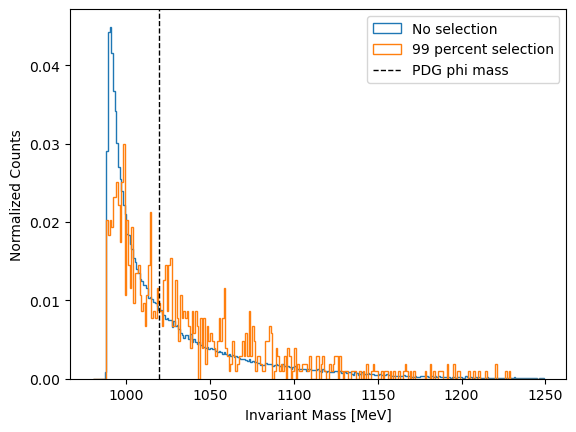

Epoch 2
-------------------------------
Classifier training loss: -4.347614
Adversary training loss: 2.327655
Classifier validation loss: -4.225532
Adversary validation loss: 2.306599
Diff score: 0.975972


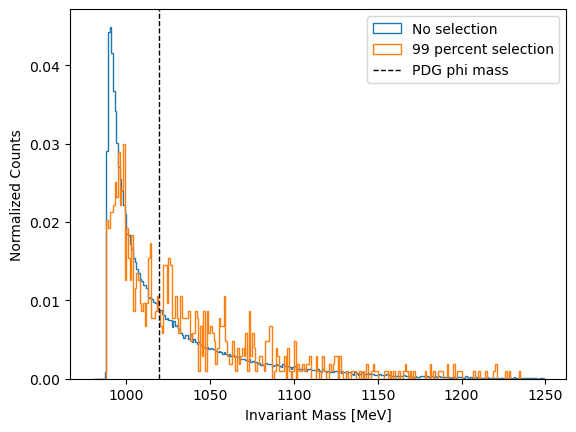

Epoch 3
-------------------------------
Classifier training loss: -4.346026
Adversary training loss: 2.335032
Classifier validation loss: -4.236379
Adversary validation loss: 2.309287
Diff score: 0.778851


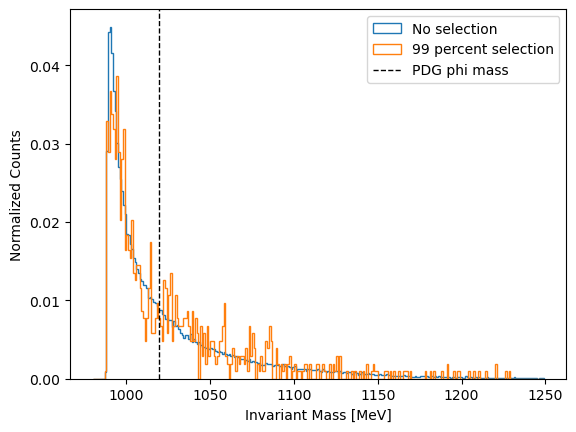

Epoch 4
-------------------------------
Classifier training loss: -4.348672
Adversary training loss: 2.338531
Classifier validation loss: -4.216916
Adversary validation loss: 2.309947
Diff score: 0.747911


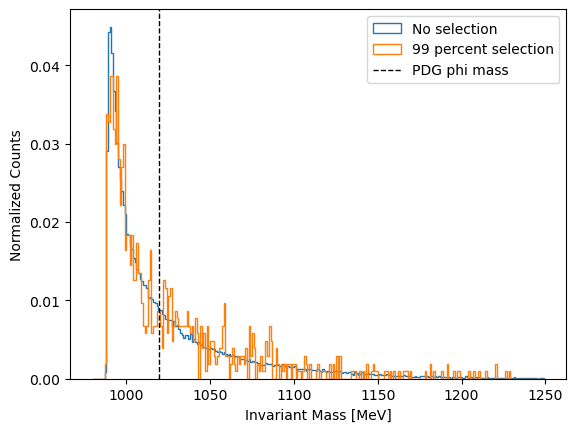

Epoch 5
-------------------------------
Classifier training loss: -4.348249
Adversary training loss: 2.343799
Classifier validation loss: -4.216917
Adversary validation loss: 2.310768
Diff score: 0.772143


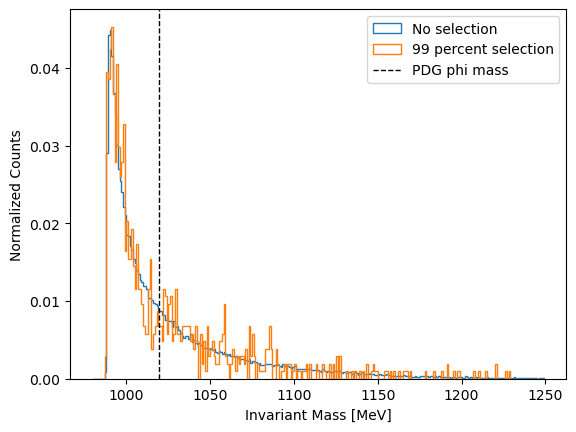

Epoch 6
-------------------------------
Classifier training loss: -4.349165
Adversary training loss: 2.351501
Classifier validation loss: -4.209811
Adversary validation loss: 2.310009
Diff score: 0.753024


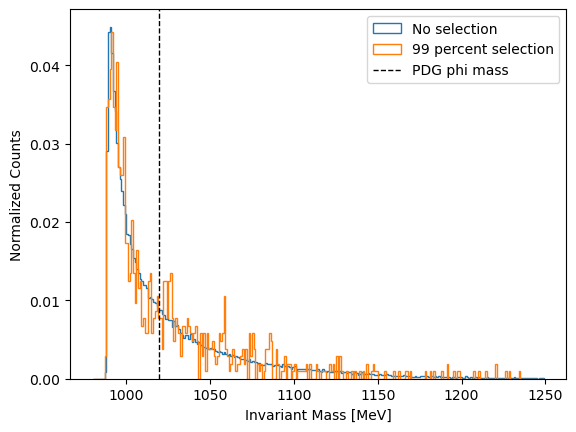

Epoch 7
-------------------------------
Classifier training loss: -4.349312
Adversary training loss: 2.351991
Classifier validation loss: -4.227689
Adversary validation loss: 2.312222
Diff score: 0.809932


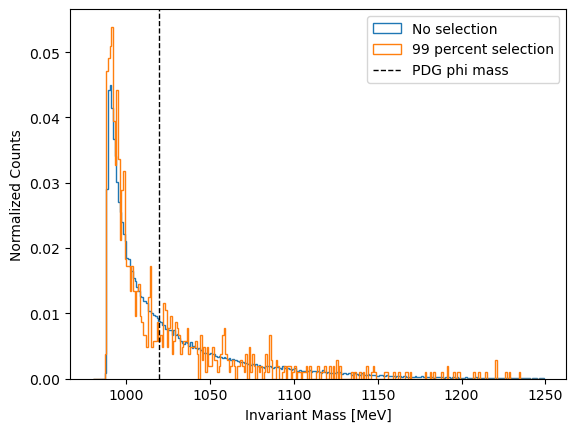

Epoch 8
-------------------------------
Classifier training loss: -4.349993
Adversary training loss: 2.362204
Classifier validation loss: -4.227490
Adversary validation loss: 2.314450
Diff score: 0.873926


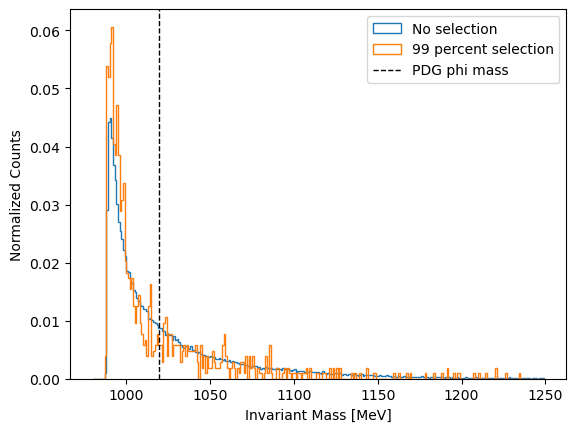

Epoch 9
-------------------------------
Classifier training loss: -4.350393
Adversary training loss: 2.369172
Classifier validation loss: -4.234963
Adversary validation loss: 2.318912
Diff score: 1.088828


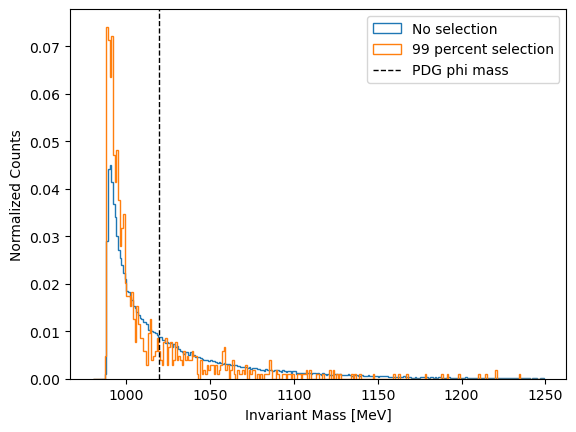

Epoch 10
-------------------------------
Classifier training loss: -4.352112
Adversary training loss: 2.361245
Classifier validation loss: -4.223320
Adversary validation loss: 2.318687
Diff score: 1.064535


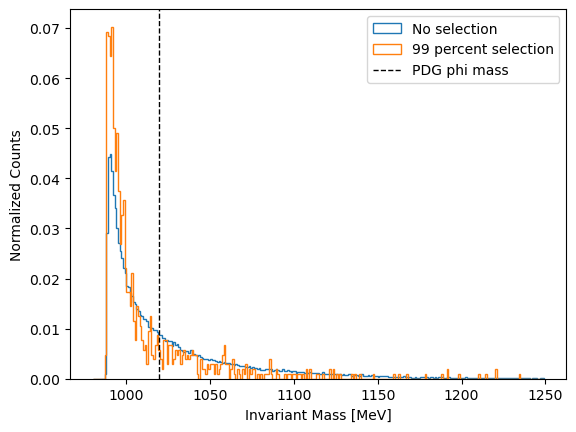

Epoch 11
-------------------------------
Classifier training loss: -4.352244
Adversary training loss: 2.374139
Classifier validation loss: -4.238833
Adversary validation loss: 2.321781
Diff score: 1.386426


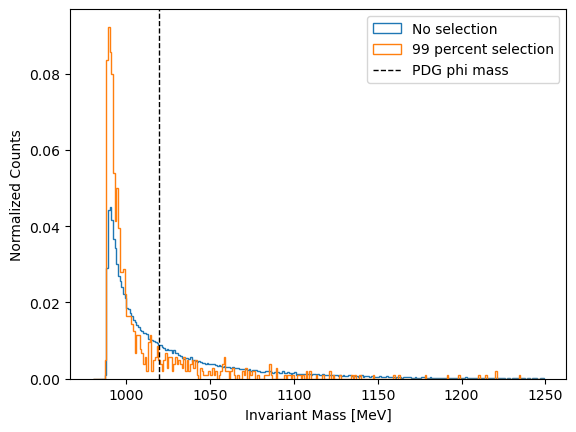

Epoch 12
-------------------------------
Classifier training loss: -4.351614
Adversary training loss: 2.377186
Classifier validation loss: -4.254225
Adversary validation loss: 2.322990
Diff score: 1.365565


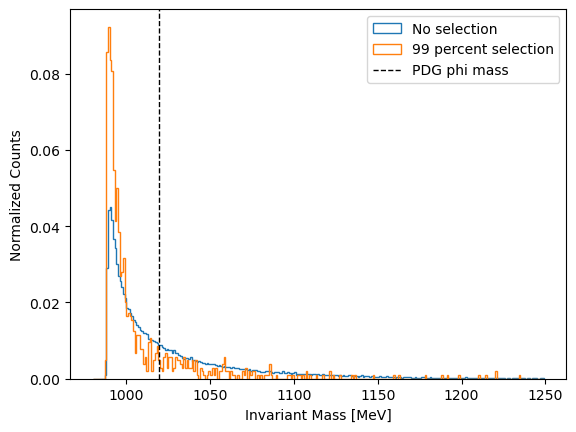

Epoch 13
-------------------------------
Classifier training loss: -4.353282
Adversary training loss: 2.377699
Classifier validation loss: -4.226636
Adversary validation loss: 2.325882
Diff score: 1.484647


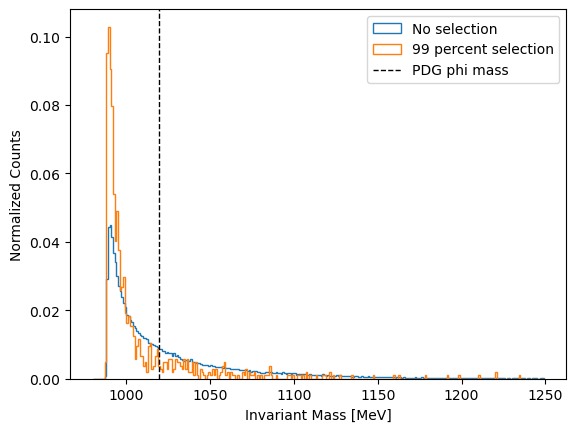

Epoch 14
-------------------------------
Classifier training loss: -4.351792
Adversary training loss: 2.384051
Classifier validation loss: -4.231210
Adversary validation loss: 2.324761
Diff score: 1.521840


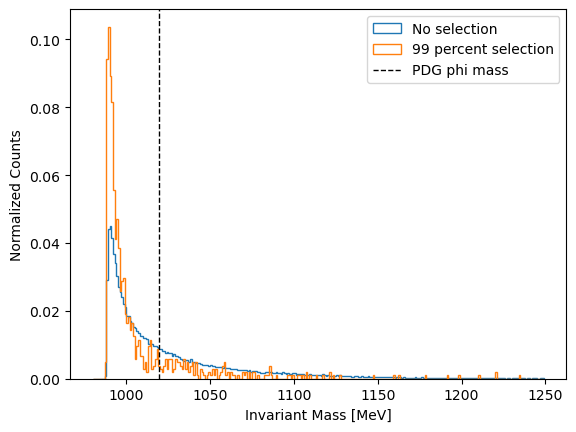

Epoch 15
-------------------------------
Classifier training loss: -4.352520
Adversary training loss: 2.384123
Classifier validation loss: -4.232588
Adversary validation loss: 2.324790
Diff score: 1.541447


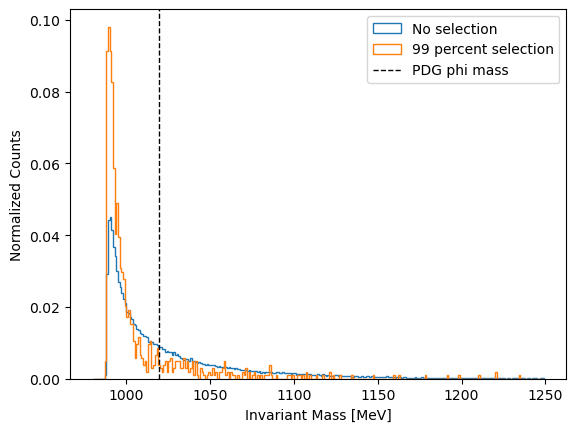

Epoch 16
-------------------------------
Classifier training loss: -4.352613
Adversary training loss: 2.384608
Classifier validation loss: -4.238517
Adversary validation loss: 2.324692
Diff score: 1.573828


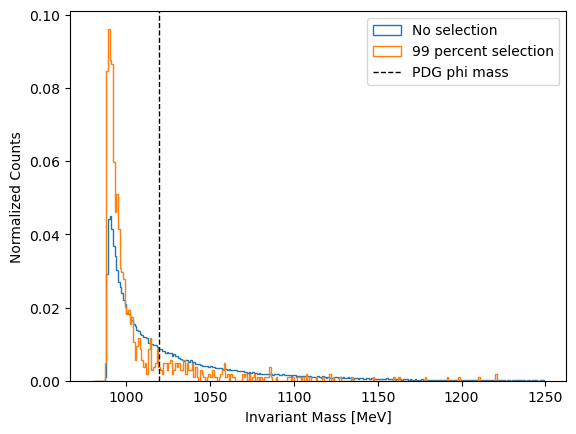

Epoch 17
-------------------------------
Classifier training loss: -4.355040
Adversary training loss: 2.379538
Classifier validation loss: -4.230777
Adversary validation loss: 2.323712
Diff score: 1.485949


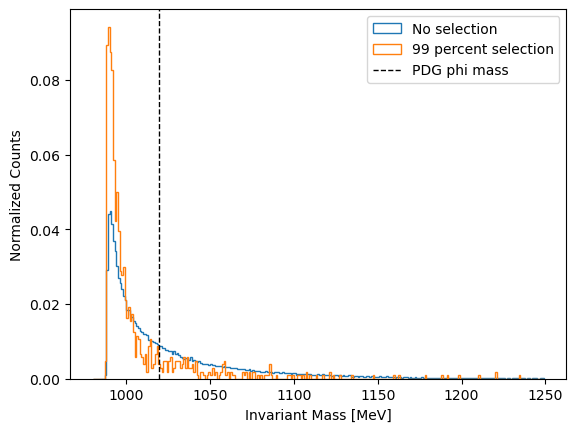

Epoch 18
-------------------------------
Classifier training loss: -4.354841
Adversary training loss: 2.385816
Classifier validation loss: -4.242645
Adversary validation loss: 2.326007
Diff score: 1.613414


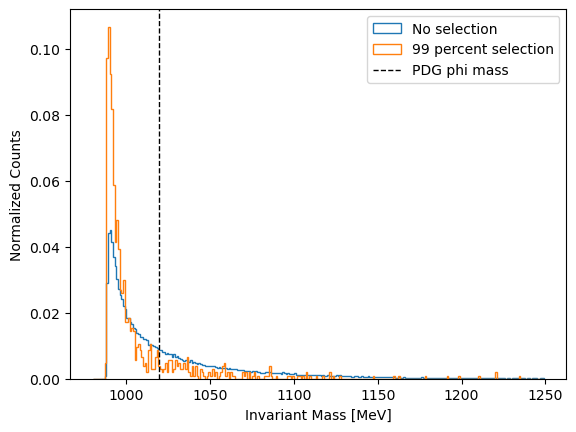

Epoch 19
-------------------------------
Classifier training loss: -4.354771
Adversary training loss: 2.372011
Classifier validation loss: -4.242842
Adversary validation loss: 2.321595
Diff score: 1.407907


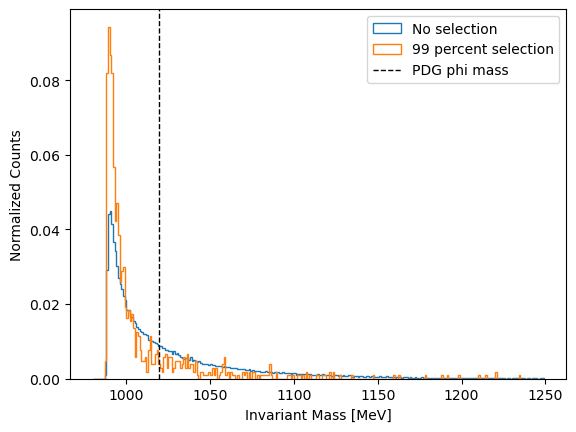

Epoch 20
-------------------------------
Classifier training loss: -4.353709
Adversary training loss: 2.376075
Classifier validation loss: -4.243710
Adversary validation loss: 2.323821
Diff score: 1.503090


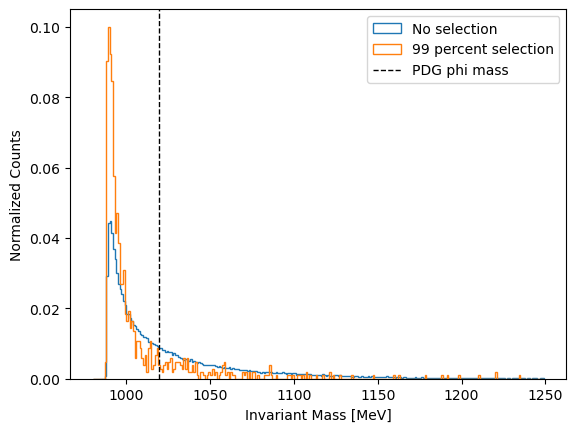

Epoch 21
-------------------------------
Classifier training loss: -4.355202
Adversary training loss: 2.378270
Classifier validation loss: -4.235702
Adversary validation loss: 2.320965
Diff score: 1.330811


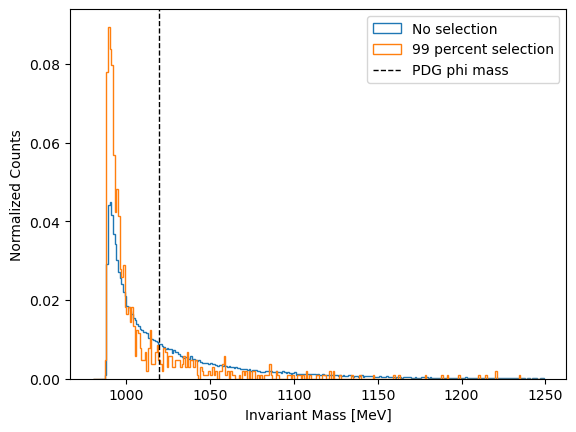

Epoch 22
-------------------------------
Classifier training loss: -4.355113
Adversary training loss: 2.385481
Classifier validation loss: -4.220769
Adversary validation loss: 2.322178
Diff score: 1.515159


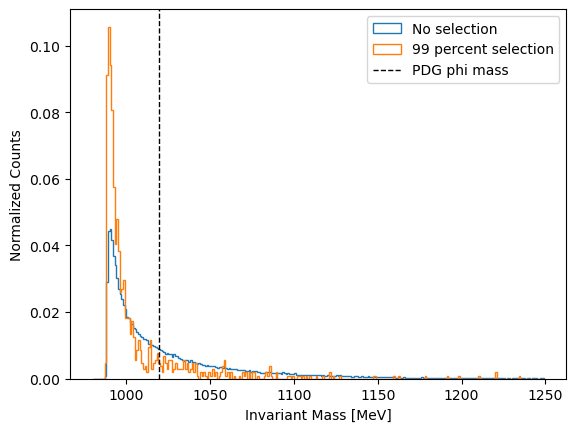

Epoch 23
-------------------------------
Classifier training loss: -4.354982
Adversary training loss: 2.377328
Classifier validation loss: -4.234443
Adversary validation loss: 2.321029
Diff score: 1.431569


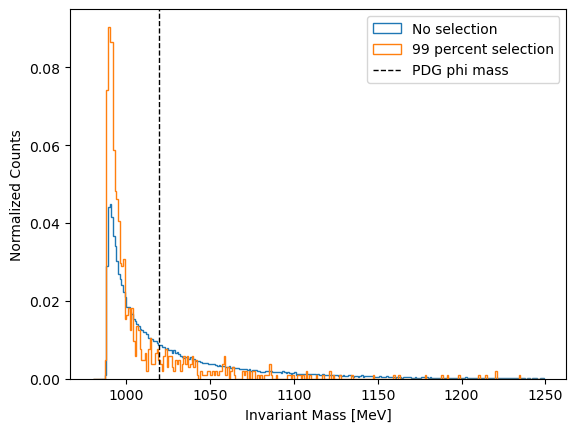

Epoch 24
-------------------------------
Classifier training loss: -4.356180
Adversary training loss: 2.375331
Classifier validation loss: -4.227025
Adversary validation loss: 2.321903
Diff score: 1.411896


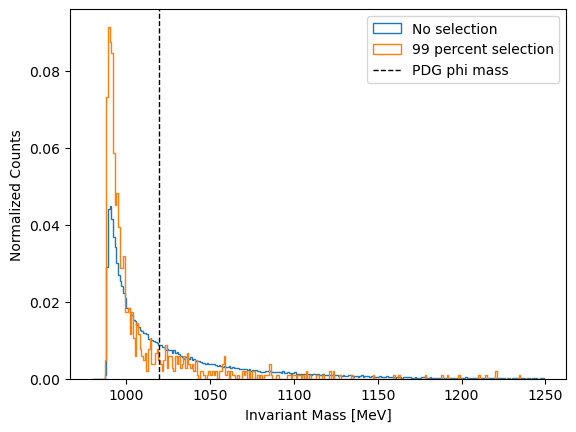

Epoch 25
-------------------------------
Classifier training loss: -4.355762
Adversary training loss: 2.372856
Classifier validation loss: -4.227363
Adversary validation loss: 2.316562
Diff score: 1.184643


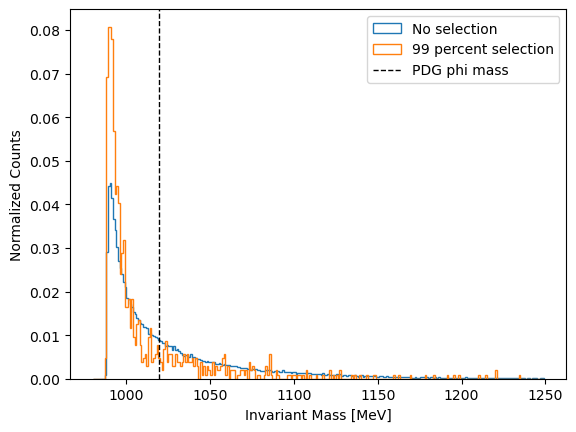

Epoch 26
-------------------------------
Classifier training loss: -4.356470
Adversary training loss: 2.366135
Classifier validation loss: -4.239517
Adversary validation loss: 2.320089
Diff score: 1.337271


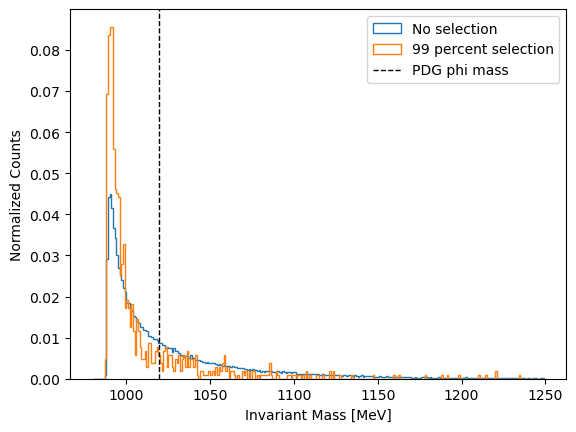

Epoch 27
-------------------------------
Classifier training loss: -4.356233
Adversary training loss: 2.374964
Classifier validation loss: -4.231328
Adversary validation loss: 2.319242
Diff score: 1.434450


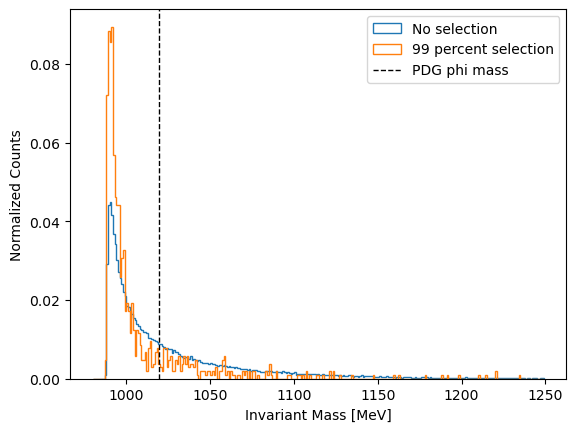

Epoch 28
-------------------------------
Classifier training loss: -4.356704
Adversary training loss: 2.363337
Classifier validation loss: -4.243736
Adversary validation loss: 2.318308
Diff score: 1.260050


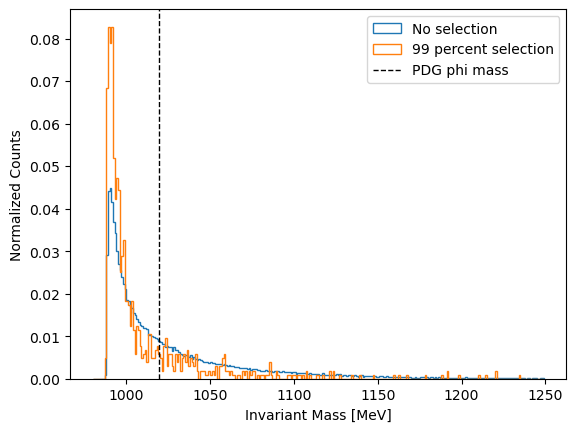

Epoch 29
-------------------------------
Classifier training loss: -4.356845
Adversary training loss: 2.369878
Classifier validation loss: -4.241603
Adversary validation loss: 2.324307
Diff score: 1.697016


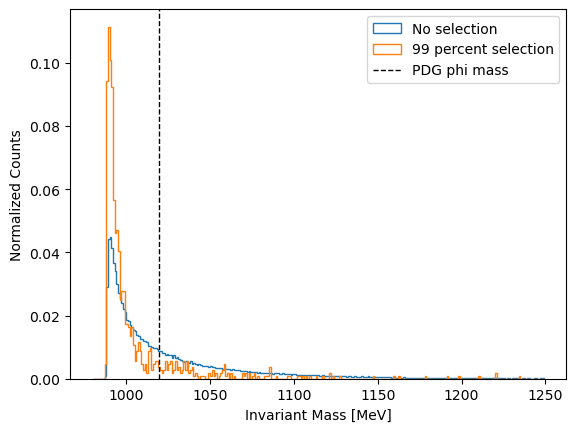

Epoch 30
-------------------------------
Classifier training loss: -4.356051
Adversary training loss: 2.370642
Classifier validation loss: -4.241381
Adversary validation loss: 2.321682
Diff score: 1.475200


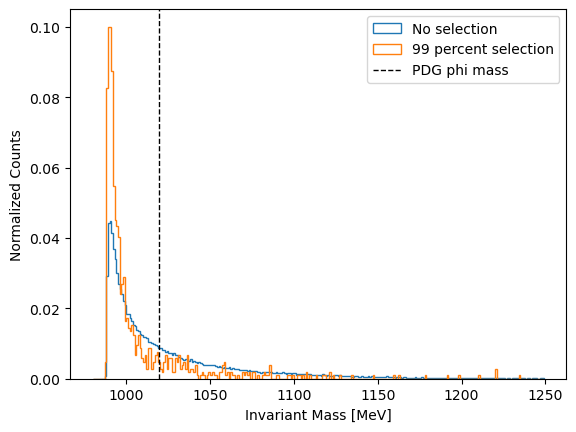

Epoch 31
-------------------------------
Classifier training loss: -4.358173
Adversary training loss: 2.365760
Classifier validation loss: -4.232012
Adversary validation loss: 2.317539
Diff score: 1.246160


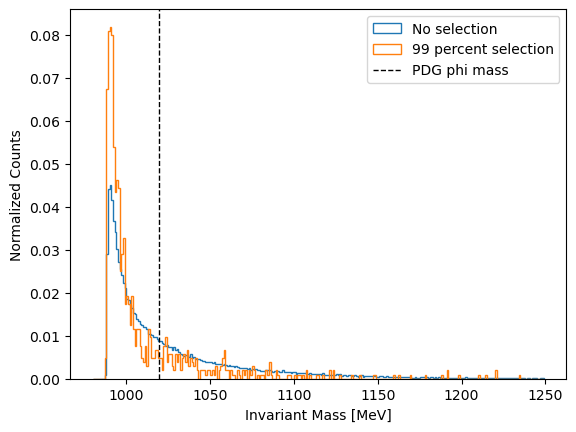

Epoch 32
-------------------------------
Classifier training loss: -4.359205
Adversary training loss: 2.364483
Classifier validation loss: -4.239608
Adversary validation loss: 2.320865
Diff score: 1.504068


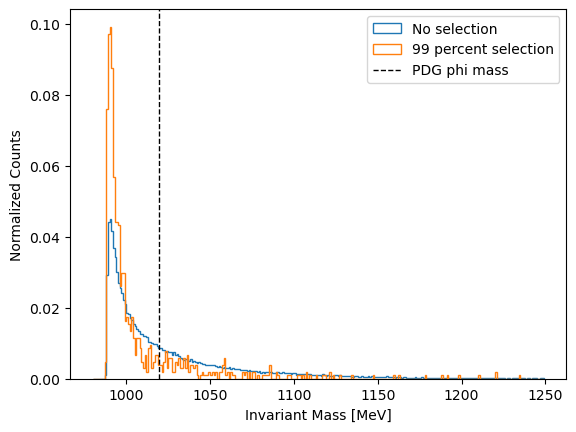

Epoch 33
-------------------------------
Classifier training loss: -4.358775
Adversary training loss: 2.359510
Classifier validation loss: -4.229692
Adversary validation loss: 2.319497
Diff score: 1.450363


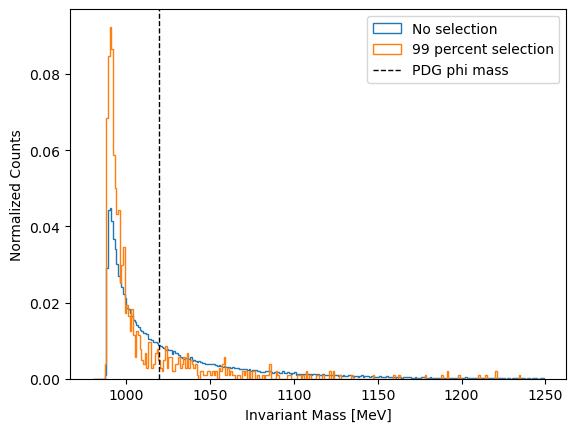

Epoch 34
-------------------------------
Classifier training loss: -4.358169
Adversary training loss: 2.361115
Classifier validation loss: -4.238160
Adversary validation loss: 2.318677
Diff score: 1.333608


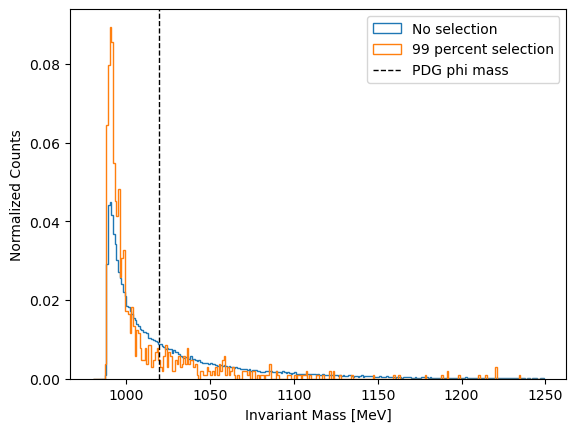

Epoch 35
-------------------------------
Classifier training loss: -4.358315
Adversary training loss: 2.357866
Classifier validation loss: -4.239774
Adversary validation loss: 2.318103
Diff score: 1.407939


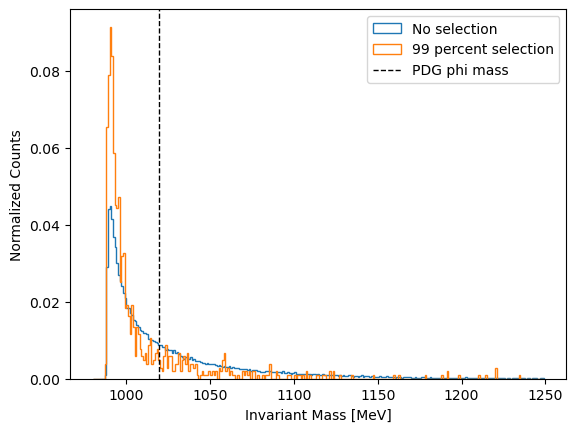

Epoch 36
-------------------------------
Classifier training loss: -4.359870
Adversary training loss: 2.351036
Classifier validation loss: -4.242823
Adversary validation loss: 2.314079
Diff score: 1.066485


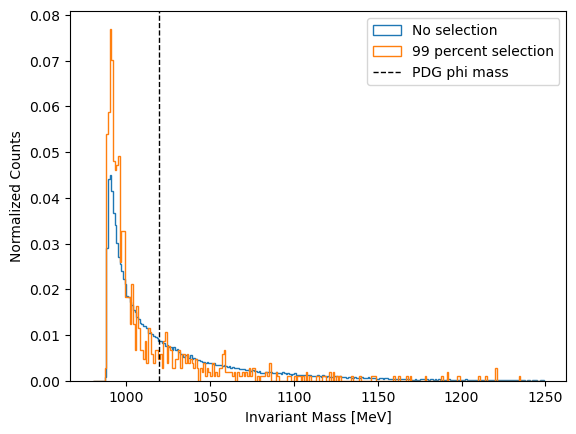

Epoch 37
-------------------------------
Classifier training loss: -4.359548
Adversary training loss: 2.349095
Classifier validation loss: -4.232028
Adversary validation loss: 2.317018
Diff score: 1.176106


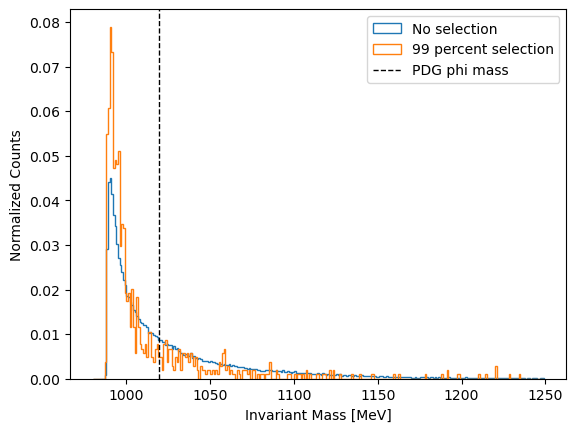

Epoch 38
-------------------------------
Classifier training loss: -4.359628
Adversary training loss: 2.353504
Classifier validation loss: -4.239083
Adversary validation loss: 2.318451
Diff score: 1.273109


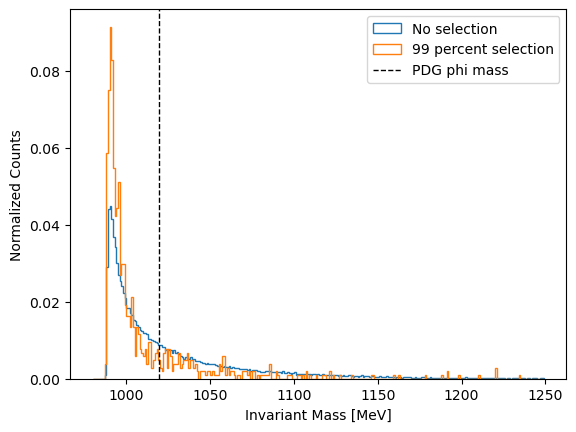

Epoch 39
-------------------------------
Classifier training loss: -4.360445
Adversary training loss: 2.345851
Classifier validation loss: -4.242788
Adversary validation loss: 2.314202
Diff score: 1.013593


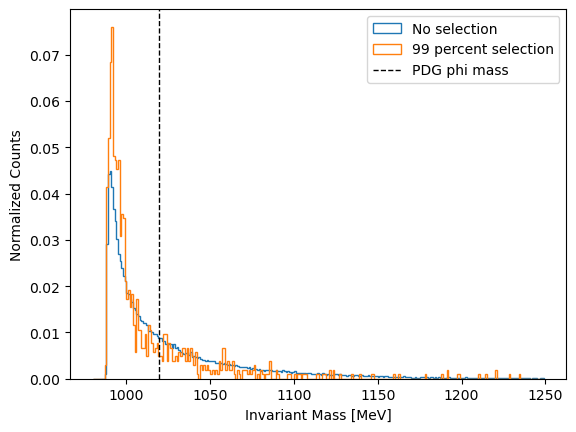

Epoch 40
-------------------------------
Classifier training loss: -4.361311
Adversary training loss: 2.348767
Classifier validation loss: -4.247251
Adversary validation loss: 2.315455
Diff score: 1.181711


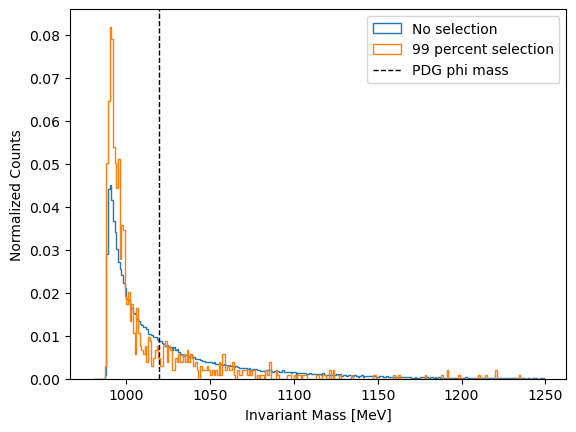

Epoch 41
-------------------------------
Classifier training loss: -4.362544
Adversary training loss: 2.347276
Classifier validation loss: -4.251069
Adversary validation loss: 2.314498
Diff score: 1.053752


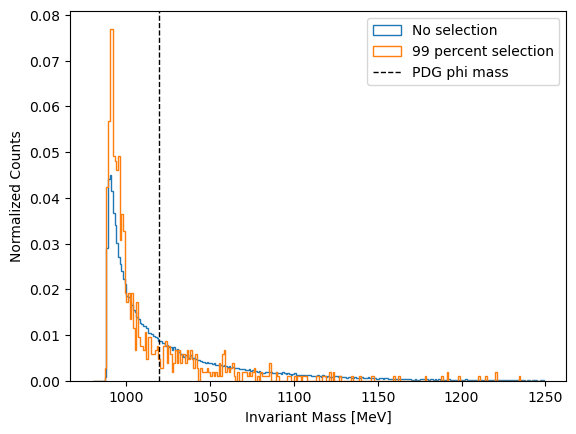

Epoch 42
-------------------------------
Classifier training loss: -4.361347
Adversary training loss: 2.341975
Classifier validation loss: -4.237108
Adversary validation loss: 2.311256
Diff score: 0.904740


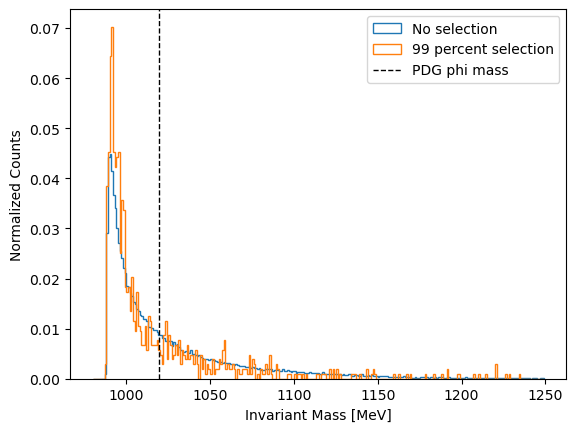

Epoch 43
-------------------------------
Classifier training loss: -4.361679
Adversary training loss: 2.350100
Classifier validation loss: -4.239285
Adversary validation loss: 2.313760
Diff score: 1.064085


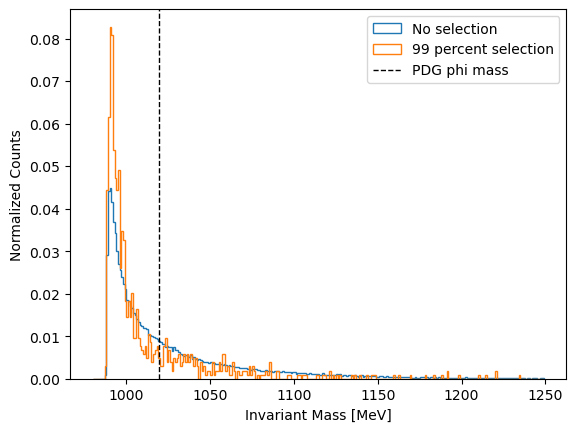

Epoch 44
-------------------------------
Classifier training loss: -4.362761
Adversary training loss: 2.343050
Classifier validation loss: -4.242305
Adversary validation loss: 2.311602
Diff score: 0.875148


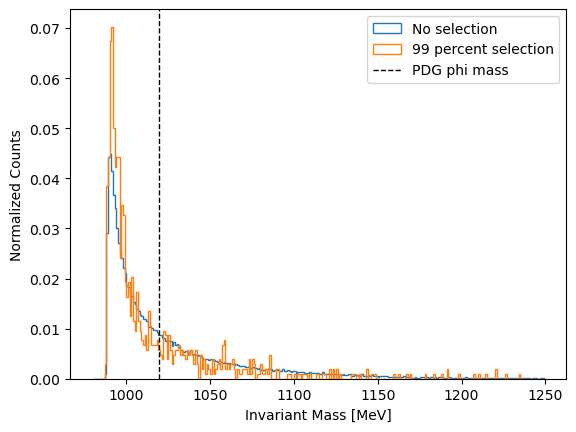

Epoch 45
-------------------------------
Classifier training loss: -4.361491
Adversary training loss: 2.337150
Classifier validation loss: -4.249843
Adversary validation loss: 2.312099
Diff score: 0.941767


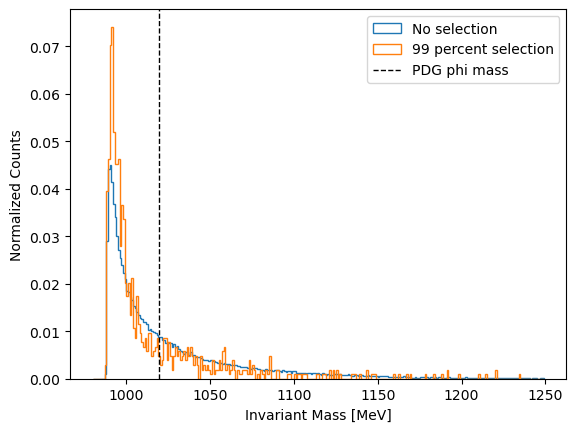

Epoch 46
-------------------------------
Classifier training loss: -4.364890
Adversary training loss: 2.340182
Classifier validation loss: -4.242605
Adversary validation loss: 2.313454
Diff score: 0.882122


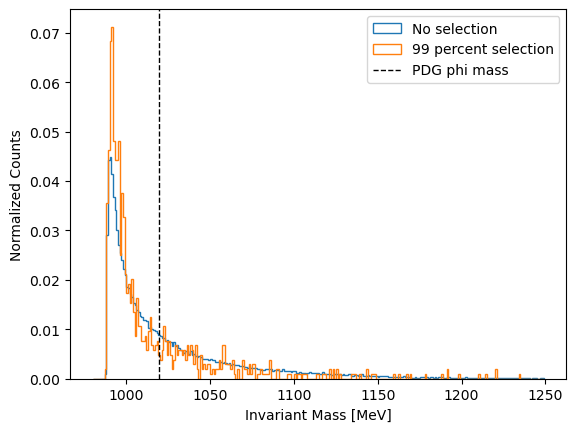

Epoch 47
-------------------------------
Classifier training loss: -4.365581
Adversary training loss: 2.333384
Classifier validation loss: -4.248363
Adversary validation loss: 2.311799
Diff score: 0.889670


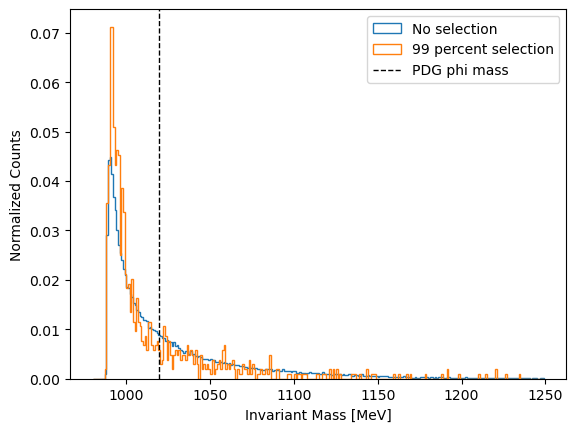

Epoch 48
-------------------------------
Classifier training loss: -4.365113
Adversary training loss: 2.332365
Classifier validation loss: -4.250943
Adversary validation loss: 2.310073
Diff score: 0.839870


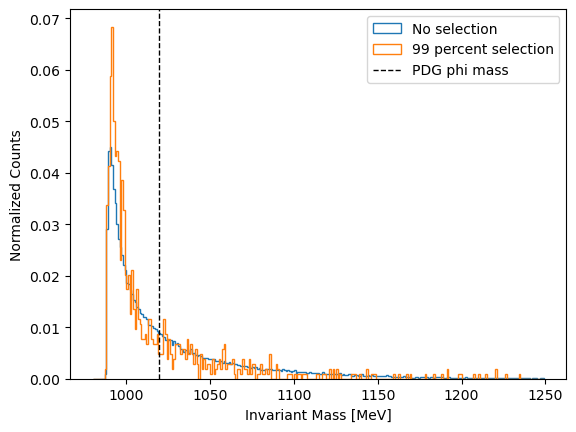

Epoch 49
-------------------------------
Classifier training loss: -4.366061
Adversary training loss: 2.331469
Classifier validation loss: -4.245285
Adversary validation loss: 2.311808
Diff score: 0.902258


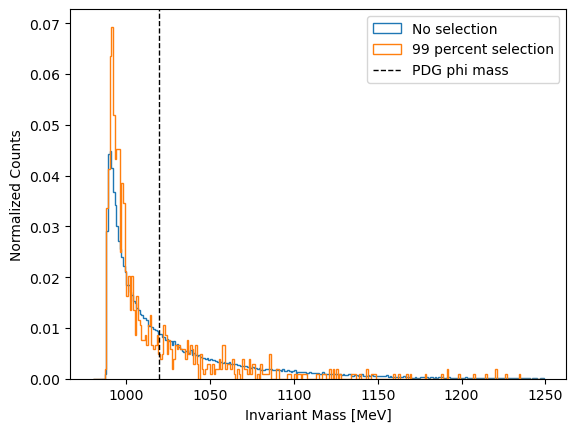

Epoch 50
-------------------------------
Classifier training loss: -4.366626
Adversary training loss: 2.329244
Classifier validation loss: -4.243302
Adversary validation loss: 2.310296
Diff score: 0.844992


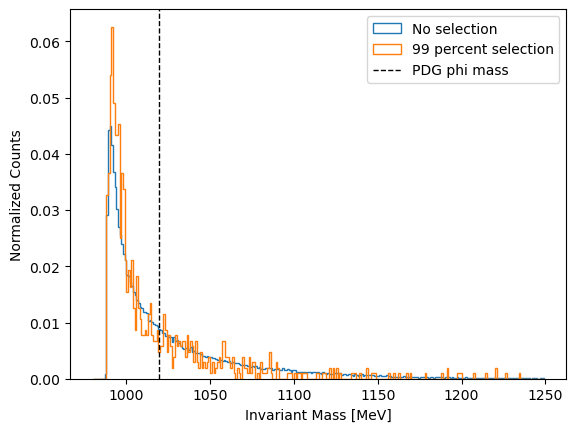

Done!


In [813]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = train_full_orig(train_full_loader, train_full_loader_bkg, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, device, adv_steps = 2)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)


    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = validate_full(val_full_loader, val_full_loader_bkg, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Get the diff_score
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
    per = np.percentile(df_bkg['Class_adv'],99)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000* df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2) )

    print(f"Diff score: {diff_scores[-1]:>7f}")

    plt.figure()
    plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
    plt.hist(1000*df_cut.InvM, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
    plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
    plt.xlabel('Invariant Mass [MeV]')
    plt.ylabel('Normalized Counts')
    plt.legend()
    plt.show()

    # Keep a running copy of the model with the lowest loss
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

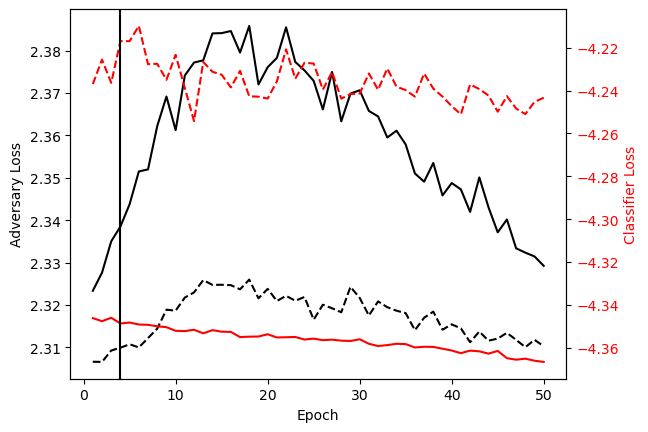

In [814]:
# Training Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



## Test adversarially trained models

Test AUROC: 0.9946


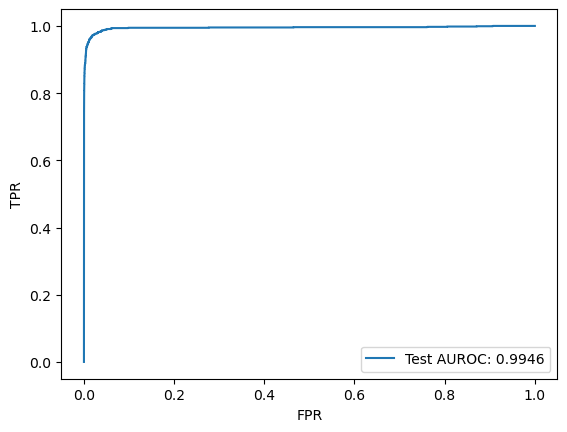

In [815]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

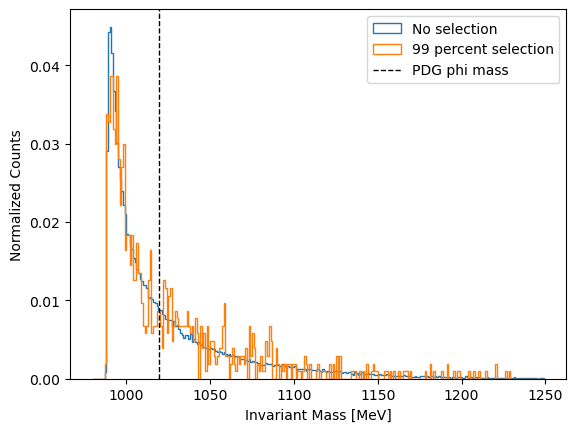

In [816]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [817]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.6892355093590588
5.6971428571428575


Test AUROC: 0.9934


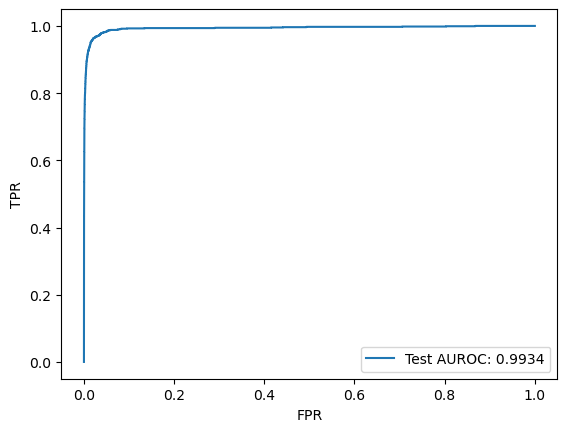

In [818]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

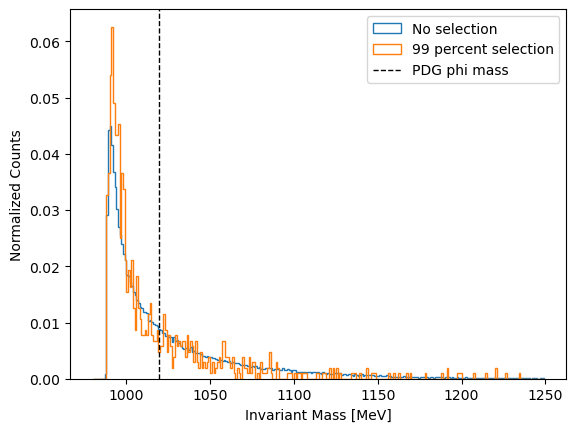

In [822]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [820]:
# Save the adversarially trained models
#torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/classifier_adv_2021_v9_pass5_run"+str(run)+"_limited.pt")
#torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/adversary_adv_2021_v9_pass5_run"+str(run)+"_limited.pt")